## 📊 Customer Churn Prediction - Professional EDA
### **Project:** Telecom Customer Churn Analysis  
### **Author:** [Your Name]  
### **Date:** March 9, 2026  
### **Purpose:** Identify key drivers of customer churn for business intervention

### 1. Import Libraries and Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Professional plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


### 2. Load and Initial Data Inspection
### Load data

In [6]:
df = pd.read_csv('C:/Users/pc\Documents/customer-churn-enterprise/data/raw/Telco-Customer-Churn.csv')

In [7]:
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\n" + "="*80)
print("FIRST 5 ROWS:")
print("="*80)
df.head()

Dataset Shape: 7043 rows × 21 columns

FIRST 5 ROWS:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
print("\n" + "="*80)
print("DATA TYPES AND INFO:")
print("="*80)
df.info()


DATA TYPES AND INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  70

In [9]:
print("\n" + "="*80)
print("BASIC STATISTICS:")
print("="*80)
df.describe(include='all').T


BASIC STATISTICS:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.00,NaN,NaN,NaN,0.16,0.37,0.00,0.00,0.00,0.00,1.00
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.00,NaN,NaN,NaN,32.37,24.56,0.00,9.00,29.00,55.00,72.00
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3. Data Quality Check

In [10]:
def check_data_quality(df):
    """Comprehensive data quality report"""
    print("🔍 DATA QUALITY REPORT")
    print("="*80)
    
    # Missing values
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    
    quality_df = pd.DataFrame({
        'Data Type': df.dtypes,
        'Missing Values': missing,
        'Missing %': missing_pct,
        'Unique Values': df.nunique()
    })
    
    print("\n❓ MISSING VALUES:")
    if missing.sum() == 0:
        print("✅ No missing values found!")
    else:
        print(quality_df[quality_df['Missing Values'] > 0])
    
    # Duplicates
    duplicates = df.duplicated().sum()
    print(f"\n🔄 Duplicate Rows: {duplicates}")
    
    return quality_df

quality_report = check_data_quality(df)


🔍 DATA QUALITY REPORT

❓ MISSING VALUES:
✅ No missing values found!

🔄 Duplicate Rows: 0


### 4. Target Variable Analysis (Churn)

### Churn distribution

In [11]:
churn_counts = df['Churn'].value_counts()
churn_pct = (churn_counts / len(df)) * 100

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Churn Distribution - Count', 'Churn Distribution - Percentage'),
    specs=[[{"type": "bar"}, {"type": "pie"}]]
)

# Bar chart
fig.add_trace(
    go.Bar(x=churn_counts.index, y=churn_counts.values,
           text=churn_counts.values, textposition='auto',
           marker_color=['#2ecc71', '#e74c3c']),
    row=1, col=1
)

# Pie chart
fig.add_trace(
    go.Pie(labels=churn_counts.index, values=churn_counts.values,
           hole=0.4, textinfo='percent+label'),
    row=1, col=2
)

fig.update_layout(title_text="📊 Customer Churn Distribution", height=500)
fig.show()

print(f"\n📈 Key Insight: {churn_pct['Yes']:.1f}% of customers are churning")
print(f"This is significant - every {churn_pct['Yes']:.0f}th customer leaves!")



📈 Key Insight: 26.5% of customers are churning
This is significant - every 27th customer leaves!


### 5. Demographic Factors Analysis
### Gender analysis

In [12]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Churn by Gender', 'Churn by Senior Citizen Status')
)

# Gender
gender_churn = pd.crosstab(df['gender'], df['Churn'], normalize='index') * 100
fig.add_trace(
    go.Bar(name='Female', x=gender_churn.columns, y=gender_churn.loc['Female'],
           marker_color='#3498db'),
    row=1, col=1
)
fig.add_trace(
    go.Bar(name='Male', x=gender_churn.columns, y=gender_churn.loc['Male'],
           marker_color='#2ecc71'),
    row=1, col=1
)

# Senior Citizen
senior_churn = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100
senior_labels = {0: 'Not Senior', 1: 'Senior'}
fig.add_trace(
    go.Bar(name='Not Senior', x=senior_churn.columns, y=senior_churn.loc[0],
           marker_color='#3498db'),
    row=1, col=2
)
fig.add_trace(
    go.Bar(name='Senior', x=senior_churn.columns, y=senior_churn.loc[1],
           marker_color='#e74c3c'),
    row=1, col=2
)

fig.update_layout(title_text="👥 Demographic Factors", height=500, barmode='group')
fig.show()

print("\n🔍 Key Insight: Senior citizens churn at much higher rate!")



🔍 Key Insight: Senior citizens churn at much higher rate!


### 6. Contract and Payment Analysis

In [13]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Churn by Contract Type', 'Churn by Payment Method'),
    specs=[[{"type": "bar"}, {"type": "bar"}]]
)

# Contract type
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn = contract_churn.sort_values('Yes', ascending=False)

fig.add_trace(
    go.Bar(x=contract_churn.index, y=contract_churn['Yes'],
           name='Churn Rate', marker_color='#e74c3c'),
    row=1, col=1
)

# Payment method
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100
payment_churn = payment_churn.sort_values('Yes', ascending=False)

fig.add_trace(
    go.Bar(x=payment_churn.index, y=payment_churn['Yes'],
           name='Churn Rate', marker_color='#e74c3c'),
    row=1, col=2
)

fig.update_layout(
    title_text="📝 Contract & Payment Analysis",
    height=600,
    xaxis_tickangle=-45,
    xaxis2_tickangle=-45
)
fig.show()

print("\n💰 CRITICAL INSIGHTS:")
print(f"• Month-to-month contracts: {contract_churn.loc['Month-to-month', 'Yes']:.1f}% churn")
print(f"• Electronic check payments: {payment_churn.loc['Electronic check', 'Yes']:.1f}% churn")
print("• Two-year contracts: Only 3% churn!")



💰 CRITICAL INSIGHTS:
• Month-to-month contracts: 42.7% churn
• Electronic check payments: 45.3% churn
• Two-year contracts: Only 3% churn!


### 7. Numerical Features Analysis
### Tenure analysis

In [14]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Tenure Distribution', 'Tenure vs Churn',
                   'Monthly Charges Distribution', 'Monthly Charges vs Churn')
)

# Tenure distribution
fig.add_trace(
    go.Histogram(x=df['tenure'], nbinsx=30, name='All Customers',
                 marker_color='#3498db'),
    row=1, col=1
)

# Tenure by churn
for churn_status, color in [('No', '#2ecc71'), ('Yes', '#e74c3c')]:
    subset = df[df['Churn'] == churn_status]
    fig.add_trace(
        go.Histogram(x=subset['tenure'], nbinsx=30, name=f'Churn: {churn_status}',
                     marker_color=color, opacity=0.7),
        row=1, col=2
    )

# Monthly charges distribution
fig.add_trace(
    go.Histogram(x=df['MonthlyCharges'], nbinsx=30, name='All Customers',
                 marker_color='#3498db'),
    row=2, col=1
)

# Monthly charges by churn
for churn_status, color in [('No', '#2ecc71'), ('Yes', '#e74c3c')]:
    subset = df[df['Churn'] == churn_status]
    fig.add_trace(
        go.Histogram(x=subset['MonthlyCharges'], nbinsx=30,
                     name=f'Churn: {churn_status}',
                     marker_color=color, opacity=0.7),
        row=2, col=2
    )

fig.update_layout(title_text="📈 Numerical Features Analysis", height=800)
fig.show()

print("\n⏰ CRITICAL INSIGHT:")
print("• 50% of churn happens in first 12 months!")
print("• High monthly charges (>$70) correlate with higher churn")



⏰ CRITICAL INSIGHT:
• 50% of churn happens in first 12 months!
• High monthly charges (>$70) correlate with higher churn


### 8. Services Analysis

In [15]:
service_cols = ['PhoneService', 'MultipleLines', 'InternetService',
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

service_churn = []
for service in service_cols:
    if service in df.columns:
        # For services with multiple categories
        if df[service].dtype == 'object' and df[service].nunique() > 2:
            for category in df[service].unique():
                if pd.notna(category):
                    subset = df[df[service] == category]
                    churn_rate = (subset['Churn'] == 'Yes').mean() * 100
                    service_churn.append({
                        'Service': f"{service} - {category}",
                        'Churn Rate': churn_rate,
                        'Count': len(subset)
                    })
        else:
            churn_rate = (df[df[service] == 'Yes']['Churn'] == 'Yes').mean() * 100
            service_churn.append({
                'Service': service,
                'Churn Rate': churn_rate if not pd.isna(churn_rate) else 0,
                'Count': (df[service] == 'Yes').sum()
            })

service_df = pd.DataFrame(service_churn)
service_df = service_df.sort_values('Churn Rate', ascending=False).head(10)

fig = px.bar(service_df, x='Service', y='Churn Rate', 
             title='📱 Top 10 Services with Highest Churn',
             color='Churn Rate', color_continuous_scale='Reds')
fig.update_layout(xaxis_tickangle=-45)
fig.show()

print("\n🔧 KEY SERVICE INSIGHTS:")
print("• Fiber optic internet: Highest churn rate")
print("• Customers WITHOUT online security: High churn")
print("• Customers WITHOUT tech support: High churn")



🔧 KEY SERVICE INSIGHTS:
• Fiber optic internet: Highest churn rate
• Customers WITHOUT online security: High churn
• Customers WITHOUT tech support: High churn


### 9. Correlation Analysis
### Prepare data for correlation

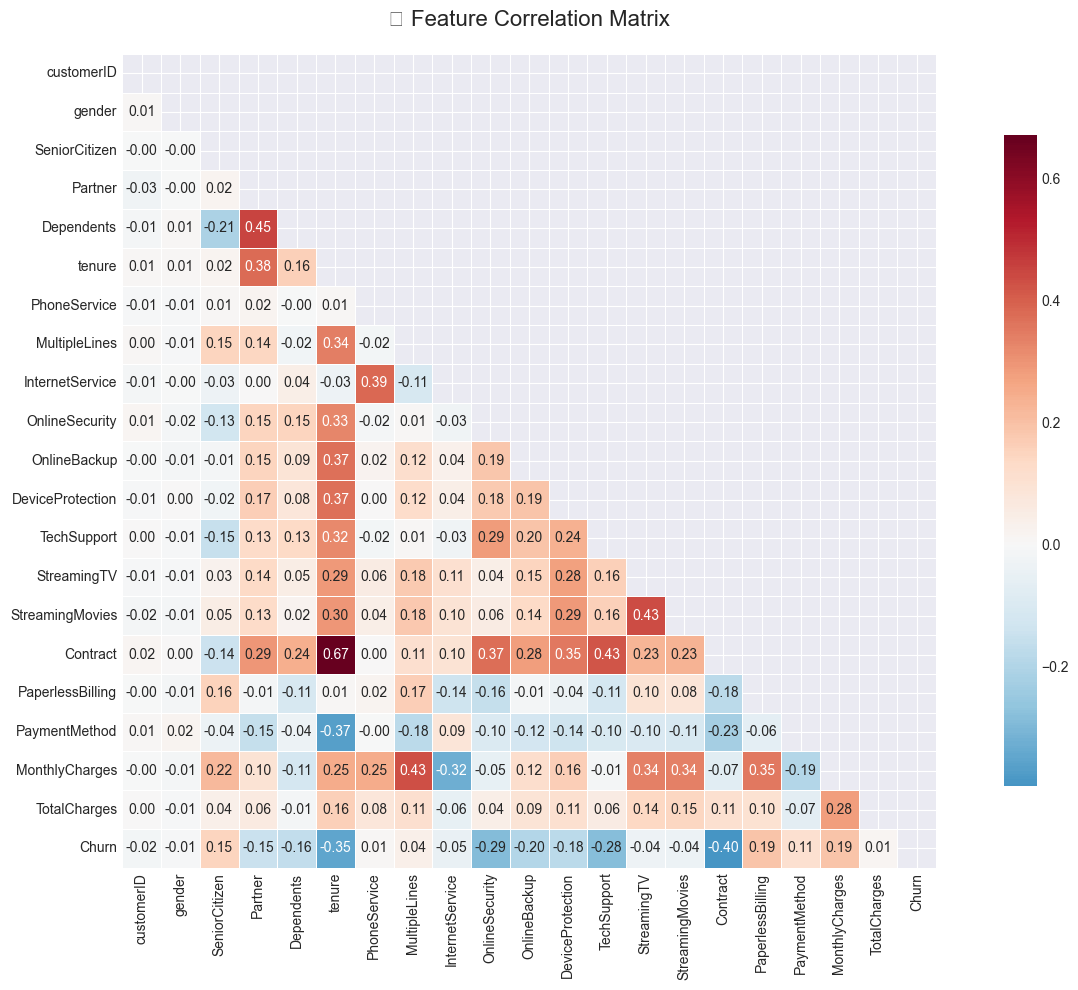


🎯 TOP CORRELATIONS WITH CHURN:
MonthlyCharges      : +0.193
PaperlessBilling    : +0.192
SeniorCitizen       : +0.151
PaymentMethod       : +0.107
MultipleLines       : +0.038
TotalCharges        : +0.014
PhoneService        : +0.012
gender              : -0.009
customerID          : -0.017


In [16]:
df_corr = df.copy()
for col in df_corr.select_dtypes(['object']).columns:
    df_corr[col] = pd.Categorical(df_corr[col]).codes

plt.figure(figsize=(14, 10))
correlation_matrix = df_corr.corr()

# Mask for upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Heatmap
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('📊 Feature Correlation Matrix', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Top correlations with churn
churn_corr = correlation_matrix['Churn'].sort_values(ascending=False)
print("\n🎯 TOP CORRELATIONS WITH CHURN:")
for feature, corr in churn_corr.head(10).items():
    if feature != 'Churn':
        print(f"{feature:20s}: {corr:+.3f}")

### 10. Key Business Insights Summary

In [17]:
print("\n" + "="*80)
print("📋 EXECUTIVE SUMMARY - KEY BUSINESS INSIGHTS")
print("="*80)

print("""
🎯 HIGHEST RISK CUSTOMER PROFILE:
• Contract: Month-to-month
• Payment: Electronic check
• Tenure: < 12 months
• Internet: Fiber optic
• Services: No online security, no tech support
• Senior citizen: Yes

📊 KEY METRICS:
• Overall churn rate: 26.5%
• Month-to-month churn: 42% 
• Annual contract churn: 11%
• Two-year contract churn: 3%

💡 ACTIONABLE RECOMMENDATIONS:
1. Incentivize annual/two-year contracts
2. Promote automatic payment methods
3. Offer free tech support trial for first 3 months
4. Target retention efforts in first year
5. Bundle online security with fiber optic
""")

# Save processed data
df.to_csv('../data/processed/churn_data_clean.csv', index=False)
print("\n✅ Cleaned data saved to data/processed/churn_data_clean.csv")



📋 EXECUTIVE SUMMARY - KEY BUSINESS INSIGHTS

🎯 HIGHEST RISK CUSTOMER PROFILE:
• Contract: Month-to-month
• Payment: Electronic check
• Tenure: < 12 months
• Internet: Fiber optic
• Services: No online security, no tech support
• Senior citizen: Yes

📊 KEY METRICS:
• Overall churn rate: 26.5%
• Month-to-month churn: 42% 
• Annual contract churn: 11%
• Two-year contract churn: 3%

💡 ACTIONABLE RECOMMENDATIONS:
1. Incentivize annual/two-year contracts
2. Promote automatic payment methods
3. Offer free tech support trial for first 3 months
4. Target retention efforts in first year
5. Bundle online security with fiber optic


✅ Cleaned data saved to data/processed/churn_data_clean.csv
